# 3Dサーフェスと散布図による学生試験成績の可視化（PROC G3D）


## エグゼクティブサマリー

このノートブックは**PROC G3D**を用いて、教育分析の設定において2つの指導介入要因が学生の成果をどのように共同で形作るかを可視化する。完全な要因計画グリッドが、週間自習時間（0～20）と前学期GPA（0～4）にわたる予測試験得点の滑らかな応答**サーフェス**を駆動し、100名の合成学生コホートが達成度バンド別の**3D散布図**パネルとして描画される。

当てはめられたサーフェスは、自習時間ゼロで予測得点約26から、上限約99に向かって上昇し、自習時間がおよそ10時間を超えると平坦化する——モデルが内包する収穫逓減の稜線である。学生パネルは個人レベルでもこのパターンを裏付ける：20名の*優秀*学生（全員が85点以上）は高GPA・高自習時間の隅に位置し、一方33名の*要注意*学生は低努力・低GPAの領域に集中する。その隅をWHEREで絞り込んだビューは、自習時間のわずかな増加が最大の限界的利得をもたらす35名の学生を特定する。


## データソース

すべてのデータは `call streaminit()` と `rand()` によりインラインで生成される——外部ファイルやネットワークアクセスはない。

**`score_grid`** — 応答サーフェスを駆動する完全な要因計画グリッド（自習時間×前学期GPAのセルごとに1行、99行）。

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `study_hours` | Num | 週間自習時間、0から20まで2刻み（X軸） |
| `prior_gpa` | Num | 前学期GPA（0～4スケール）、0から4まで0.5刻み（Y軸） |
| `pred_score` | Num | 飽和応答モデルによるモデル化された期末試験得点0～100（Z軸） |

**`students`** — 散布図用の合成個別学生コホート（100行）。

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `student_id` | Num | 学生の連番識別子 |
| `study_hours` | Num | 観測された週間自習時間（X軸） |
| `prior_gpa` | Num | 観測された前学期GPA（Y軸） |
| `exam_score` | Num | 観測された期末試験得点0～100（Z軸） |
| `cohort` | Char | 入学コホート、`秋学期` または `春学期` |
| `band` | Char | 達成度バンド：`優秀`（85以上）、`合格`（65～84）、`要注意`（65未満） |

このグリッドは意図的に99セルにサイズ設定されており、0～20の自習時間範囲と0～4のGPA範囲を完全にカバーしつつ、この環境の100観測制限内に収まるようにしている；11×9の格子により、どちらの軸も切り詰めることなくサーフェスを滑らかに保っている。


# PROC G3Dによる学生試験成績の可視化

教育研究者はしばしば、2つの操作可能な要因が共同でどのように結果を導くかを理解したいと考える。ここでは次の問いを立てる：*週間自習時間と学生の前学期GPAはどのように組み合わさって期末試験の成績を形作るのか？*

二次元グラフでは交互作用サーフェスを示せない。**PROC G3D**は`y*x=z`記法の変数から真の三次元グラフを描画し、XとYが水平面に広がり、Zが垂直に立ち上がる。ここでは次の2つの機能を用いる：

- **PLOT** — 2つの予測変数の完全なグリッド上の連続的な応答*サーフェス*。
- **SCATTER** — 個々の学生を3Dシンボルとしてプロットする。達成度バンドごとに1つのパネルを描画し、それぞれ独自のマーカー色と形状を持たせることで、3つの成果階層を比較しやすくする。

以下はすべてインラインで生成された合成データ上で実行されるため、このノートブックは完全に自己完結している。


## ステップ1 — 応答サーフェスグリッドの生成

G3Dサーフェスプロットには合理的に完全なグリッドが必要である：X-Yセルの少なくとも半分について非欠測のZ値が必要となる。`study_hours`（0から20まで2刻み）と`prior_gpa`（0から4まで0.5刻み）に対して2つの`DO`ループを入れ子にすることで、両軸を完全にカバーする11×9格子・99セルの*完全な*グリッドを保証する。

予測得点はもっともらしい飽和モデルに従う：自習時間が多くなるとリターンは逓減し、前学期GPAはおおむね線形に寄与し、両者は交互作用する（優秀な学生ほど自習時間をより効率的に得点へ変換する）。`rand('NORMAL')`による小さな再現可能なジッターが、サーフェスが完全に解析的に見えるのを防ぐ。`call streaminit()`がシードを固定するため、グリッドは再現可能である。


In [1]:
データ score_grid;
   呼出 streaminit(20260531);
   繰返 study_hours = 0 から 20 基準 2;     /* 11 values: full 0-20 range */
      繰返 prior_gpa = 0 から 4 基準 0.5;   /* 9 values  -> 99 grid cells */
         /* saturating return to study hours */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* prior achievement and an interaction term */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         もし pred_score > 100 なら pred_score = 100;
         もし pred_score < 0   なら pred_score = 0;
         出力;
      終了;
   終了;
   保持 study_hours prior_gpa pred_score;
実行;

処理 平均 データ=score_grid n MIN mean MAX maxdec=1;
   変数 study_hours prior_gpa pred_score;
   見出 study_hours = '週間自習時間'
         prior_gpa   = '前学期GPA'
         pred_score  = '予測試験得点';
実行;


                                                  The MEANS Procedure

 Variable     Label                     N     Minimum        Mean     Maximum
 ----------------------------------------------------------------------------
 study_hours  週間自習時間                   99         0.0        10.0        20.0
 prior_gpa    前学期GPA                   99         0.0         2.0         4.0
 pred_score   予測試験得点                   99        25.7        70.0        98.7
 ----------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## ステップ2 — 基本の応答サーフェスを描画する

完全なグリッドが揃ったところで、最も単純な呼び出しはプロシジャの既定値を用いてサーフェスを描画する。`PLOT y*x=z`構文は`prior_gpa`をY軸、`study_hours`をX軸、予測得点を垂直のZ軸にマッピングする。

軸には`LABEL`文でラベルを付け、グラフがきれいに読めるようにグローバルな`TITLE`/`FOOTNOTE`文でタイトルと脚注を設定する。


                                                     予測期末試験得点サーフェス                                                      
                                                    週間自習時間と前学期GPAの効果                                                    

PROC G3D Output
Data: score_grid

Variables: 週間自習時間, 前学期GPA, 予測試験得点

            週間自習時間        前学期GPA              予測試験得点
------------------  ------------  ------------------
                 0             0       25.7031536911
                 0           0.5       28.9516502743
                 0             1       32.3400787822
                 0           1.5       36.8265757618
                 0             2       40.7806886968
                 0           2.5         42.61364606
                 0             3       49.4289293966
                 0           3.5       52.6020716414
                 0             4       55.6325677612
                 2             0       36.0797021538
                 2           0.5       39.4174320298


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to 予測期末試験得点サーフェス.
NOTE: Option TITLE2 changed to 週間自習時間と前学期GPAの効果.
NOTE: Option FOOTNOTE changed to 合成教育分析データ .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


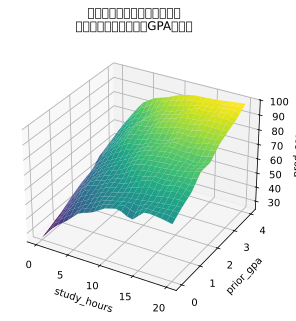

In [2]:
GOPTIONS reset=GLOBAL BORDER;

表題 '予測期末試験得点サーフェス';
title2 '週間自習時間と前学期GPAの効果';
footnote j=r '合成教育分析データ ';

処理 g3d データ=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   見出 study_hours = '週間自習時間'
         prior_gpa   = '前学期GPA'
         pred_score  = '予測試験得点';
実行;
QUIT;


## ステップ3 — 視点と軸オプションでサーフェスを調整する

いくつかのオプションでサーフェスの視認性が大きく向上する：

- **ROTATE=** と **TILT=** は視点角度（Z軸周りの度数、および視点方向へのチルト）を設定する。
- **XYTYPE=2** はY軸に平行なサーフェス線を描き、得点が自習時間とともに上昇する様子を強調する。
- **SIDE** は側壁を追加し、立体的で彫刻的な見た目にする。
- **GRID** は主目盛に参照線を追加する。
- **ZMIN=/ZMAX=** と **ZTICKNUM=** 系のオプションは得点軸を0～100の全範囲に固定し、サーフェスが視覚的に誇張されないようにする。一方 **XTICKNUM=/YTICKNUM=** は床面の目盛を制御する。
- **NAME=** と **DESCRIPTION=** は出力カタログ内でグラフにラベルを付ける。


                                                  予測試験得点サーフェス（スタイル適用版）                                                  
                                                    回転・チルト・軸スケール調整済み                                                    

PROC G3D Output
Data: score_grid

Variables: 週間自習時間, 前学期GPA, 予測試験得点

            週間自習時間        前学期GPA              予測試験得点
------------------  ------------  ------------------
                 0             0       25.7031536911
                 0           0.5       28.9516502743
                 0             1       32.3400787822
                 0           1.5       36.8265757618
                 0             2       40.7806886968
                 0           2.5         42.61364606
                 0             3       49.4289293966
                 0           3.5       52.6020716414
                 0             4       55.6325677612
                 2             0       36.0797021538
                 2           0.5       39.4174320298


NOTE: Option TITLE changed to 予測試験得点サーフェス（スタイル適用版）.
NOTE: Option TITLE2 changed to 回転・チルト・軸スケール調整済み.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


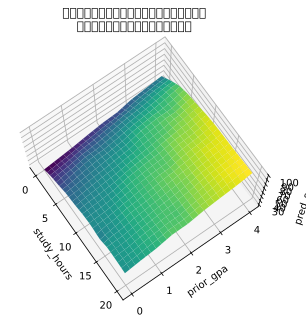

In [3]:
表題 '予測試験得点サーフェス（スタイル適用版）';
title2 '回転・チルト・軸スケール調整済み';

処理 g3d データ=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="スタイル適用済み試験得点応答サーフェス";
   見出 study_hours = '週間自習時間'
         prior_gpa   = '前学期GPA'
         pred_score  = '予測試験得点';
実行;
QUIT;


## ステップ4 — 複数の視点角度からサーフェスを比較する

3Dサーフェスはそれ自身のピークの背後に構造を隠すことがあるため、同じサーフェスを複数の回転角度から描画すると役立つ。ここでは固定のチルトを共有しつつ**ROTATE=**角度を30度、90度、150度と変化させる3つのPROC G3Dステップを発行し、稜線を正面・側面・背面から確認できるようにする。


                                                        応答サーフェス                                                         
                                                  ROTATE = 30 （固定チルト）                                                   

PROC G3D Output
Data: score_grid

Variables: 週間自習時間, 前学期GPA, 予測試験得点

            週間自習時間        前学期GPA              予測試験得点
------------------  ------------  ------------------
                 0             0       25.7031536911
                 0           0.5       28.9516502743
                 0             1       32.3400787822
                 0           1.5       36.8265757618
                 0             2       40.7806886968
                 0           2.5         42.61364606
                 0             3       49.4289293966
                 0           3.5       52.6020716414
                 0             4       55.6325677612
                 2             0       36.0797021538
                 2           0.5       39.4174320298


NOTE: Option TITLE changed to 応答サーフェス.
NOTE: Option TITLE2 changed to ROTATE = 30 （固定チルト）.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to 応答サーフェス.
NOTE: Option TITLE2 changed to ROTATE = 90 （固定チルト）.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to 応答サーフェス.
NOTE: Option TITLE2 changed to ROTATE = 150 （固定チルト）.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


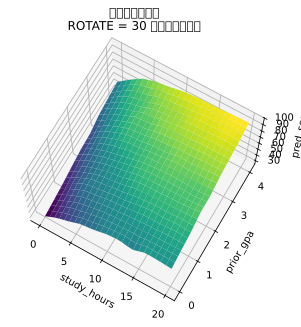

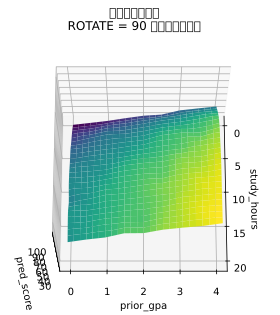

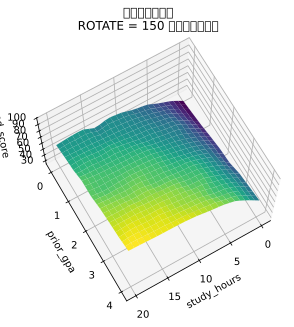

In [4]:
%macro angle(deg);
   表題 '応答サーフェス';
   title2 "ROTATE = &deg （固定チルト）";
   処理 g3d データ=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      見出 study_hours = '週間自習時間'
            prior_gpa   = '前学期GPA'
            pred_score  = '予測試験得点';
   実行;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);


## ステップ5 — 合成学生コホートを生成する

サーフェスはモデルにすぎない；実際の学生はその周りに散らばる。ここでは2つの入学コホート（`秋学期`、`春学期`）から抽出した100名の個々の学生をシミュレートする。各学生は観測された自習時間、前学期GPA、そして同じ応答ロジックに加えてより大きな個人差から生成されたノイズを含む実現試験得点を持つ。

次に試験得点から達成度**バンド**を導出する：`優秀`（85以上）、`合格`（65～84）、`要注意`（65未満）。以下のPROC FREQクロス集計は、バンドが2つのコホートにどのように分布するかを報告する。`rand('UNIFORM')`と`rand('NORMAL')`が乱数を供給し、シードにより再現可能性が保たれる。


                                                        応答サーフェス                                                         
                                                  ROTATE = 150 （固定チルト）                                                  

                                                   The FREQ Procedure

                                   Cumulative
達成度バンド                Frequency    Frequency
------------------------------------------------
優秀                           20           20
合格                           47           67
要注意                          33          100

Table of 入学コホート by 達成度バンド

入学コホート             |        優秀 |        合格 |       要注意 |      Total
-------------------+-----------+-----------+-----------+-----------
春学期                |        14 |        27 |        18 |         59
-------------------+-----------+-----------+-----------+-----------
秋学期                |         6 |        20 |        15 |         41
-------------------+-----------+-----------


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


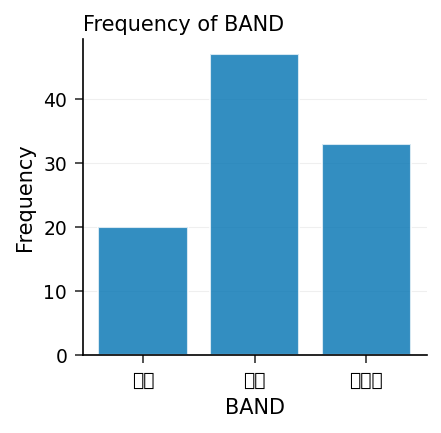

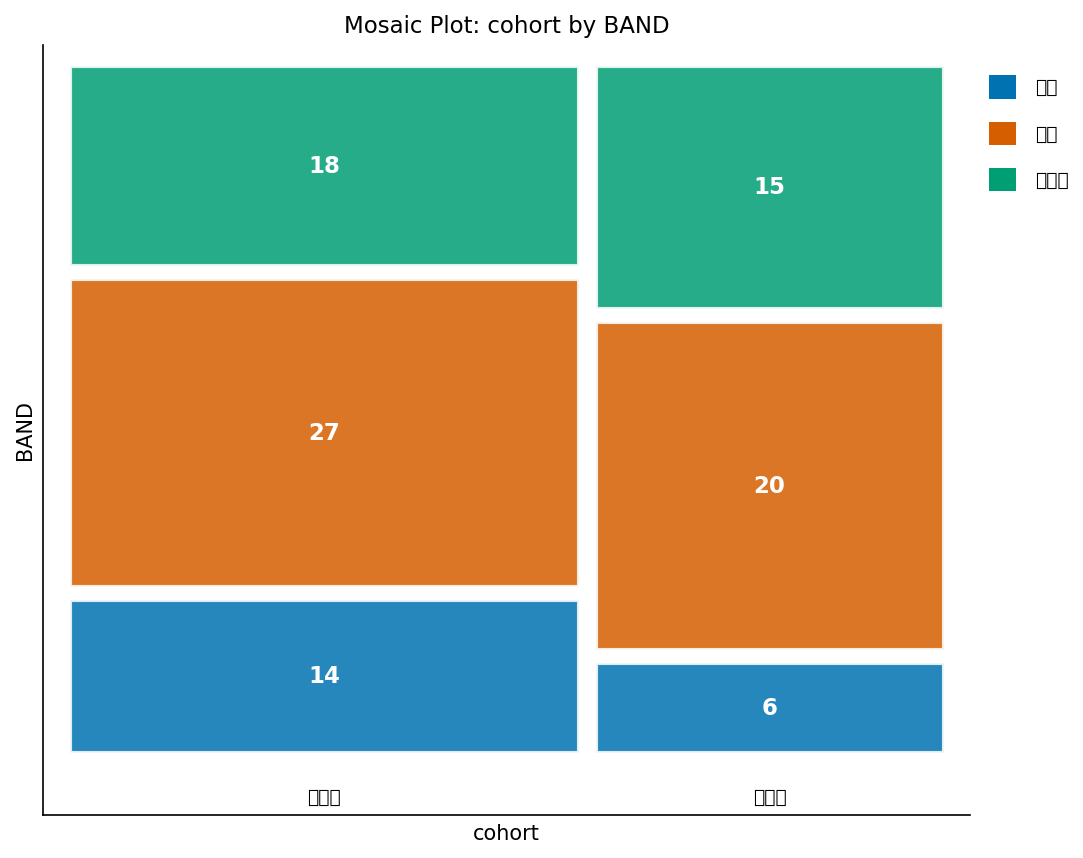

In [5]:
データ students;
   呼出 streaminit(99001);
   長さ cohort $12 BAND $12;
   繰返 student_id = 1 から 100;
      もし rand('UNIFORM') < 0.5 なら cohort = '秋学期';
      他 cohort = '春学期';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      もし exam_score > 100 なら exam_score = 100;
      もし exam_score < 0   なら exam_score = 0;

      もし exam_score >= 85 なら BAND = '優秀';
      他 もし exam_score >= 65 なら BAND = '合格';
      他 BAND = '要注意';

      出力;
   終了;
   保持 student_id cohort study_hours prior_gpa exam_score BAND;
実行;

処理 度数 データ=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   見出 BAND = '達成度バンド' cohort = '入学コホート';
実行;


## ステップ6 — 達成度バンド別に学生を3D散布図パネルとしてプロットする

**SCATTER**文は各学生を3Dシンボルとして配置する。3つの達成度階層を読み取りやすくするため、バンドごとに1つのパネルを描画し、それぞれ**WHERE**でフィルタし、独自のリテラルな**COLOR=**と**SHAPE=**を与える：*優秀*には緑のダイヤモンド（`SHAPE=diamond`）、*合格*には青のマーカー（`SHAPE=club`）、*要注意*には赤のマーカー（`SHAPE=spade`）。**SIZE=**はマーカーを拡大し、**GRID**は床面の参照線を追加し、**NONEEDLE**は垂直の落下線を除去し、**ZMIN=/ZMAX=**はすべてのパネルを同じ0～100の得点軸に固定し、3つのビューを直接比較できるようにする。

各バンドは独自のPROC G3Dステップを持ち、そのWHEREフィルタがきれいに適用され、マーカースタイルが明確になる。


                                                         優秀な学生                                                          
                                                        試験得点85以上                                                        

PROC G3D Output
Data: students

Variables: student_id, cohort, 週間自習時間, 前学期GPA, 期末試験得点, BAND

student_id      cohort              週間自習時間        前学期GPA              期末試験得点        BAND
----------  ----------  ------------------  ------------  ------------------  ----------
         2         春学期       19.2134883194  2.6467742616       90.3663886999          優秀
         5         春学期       15.5520919174  2.7102003827       94.9419468332          優秀
        10         春学期       14.2302640951  3.8791496428                 100          優秀
        17         春学期       13.7403346635  2.7462821708       89.6648779222          優秀
        25         秋学期       18.7592154739   3.639636185                 100          優秀
        32         春学期       18.927384836


NOTE: Option FOOTNOTE changed to 100名の合成学生コホートから .
NOTE: Option TITLE changed to 優秀な学生.
NOTE: Option TITLE2 changed to 試験得点85以上.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to 合格の学生.
NOTE: Option TITLE2 changed to 試験得点65から84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to 要注意の学生.
NOTE: Option TITLE2 changed to 試験得点65未満.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


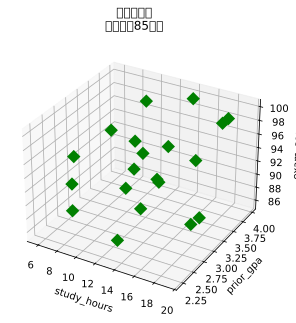

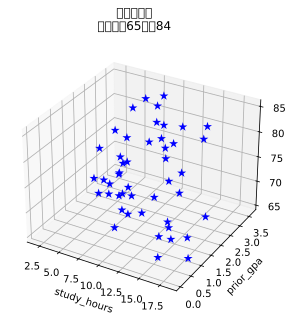

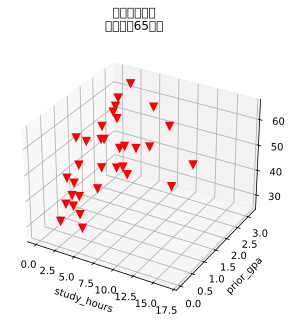

In [6]:
footnote j=r '100名の合成学生コホートから ';

/* 優秀 (exam_score >= 85): 緑のダイヤモンド */
表題 '優秀な学生';
title2 '試験得点85以上';
処理 g3d データ=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="優秀な学生";
   条件 BAND = '優秀';
   見出 study_hours = '週間自習時間'
         prior_gpa   = '前学期GPA'
         exam_score  = '期末試験得点';
実行;
QUIT;

/* 合格 (65 <= exam_score < 85): 青のクラブ */
表題 '合格の学生';
title2 '試験得点65から84';
処理 g3d データ=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="合格の学生";
   条件 BAND = '合格';
   見出 study_hours = '週間自習時間'
         prior_gpa   = '前学期GPA'
         exam_score  = '期末試験得点';
実行;
QUIT;

/* 要注意 (exam_score < 65): 赤のスペード */
表題 '要注意の学生';
title2 '試験得点65未満';
処理 g3d データ=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="要注意の学生";
   条件 BAND = '要注意';
   見出 study_hours = '週間自習時間'
         prior_gpa   = '前学期GPA'
         exam_score  = '期末試験得点';
実行;
QUIT;


## ステップ7 — 入学コホート別に散布図を分ける（BYグループ）

プログラム責任者はしばしば同じビューをコホート別に分割する必要がある。**BY**文はコホートごとに1つの散布図を生成する。G3DはBYグループのデータがソートされていることを要求するため、まずPROC SORTでソートする。各コホートは共有の0～100得点軸上に独自のラベル付き3D散布図を持ち、秋学期と春学期の分布を並べて比較しやすくする。


                                                      入学コホート別の試験結果                                                      
                                                  コホート別の3D散布図（秋学期・春学期）                                                  

PROC G3D Output
Data: students_sorted

Variables: student_id, cohort, 週間自習時間, 前学期GPA, 期末試験得点, BAND

student_id      cohort              週間自習時間        前学期GPA              期末試験得点        BAND
----------  ----------  ------------------  ------------  ------------------  ----------
        53         春学期       10.7875369915  3.0789706431       76.6136428341          合格
       100         春学期       10.7782420031  3.5469548845                 100          優秀
         4         春学期        8.3587240648  1.1475897699       65.4995231815          合格
         5         春学期       15.5520919174  2.7102003827       94.9419468332          優秀
         2         春学期       19.2134883194  2.6467742616       90.3663886999          優秀
         7         春学期        7.90


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to 入学コホート別の試験結果.
NOTE: Option TITLE2 changed to コホート別の3D散布図（秋学期・春学期）.
NOTE: Option FOOTNOTE changed to コホートごとに1パネル .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


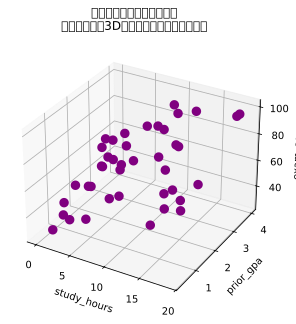

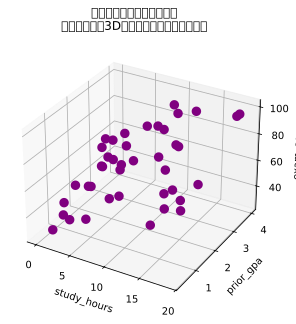

In [7]:
処理 並替 データ=students out=students_sorted;
   基準 cohort;
実行;

表題 '入学コホート別の試験結果';
title2 'コホート別の3D散布図（秋学期・春学期）';
footnote j=r 'コホートごとに1パネル ';

処理 g3d データ=students_sorted;
   基準 cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   見出 study_hours = '週間自習時間'
         prior_gpa   = '前学期GPA'
         exam_score  = '期末試験得点';
実行;
QUIT;


## ステップ8 — WHEREで要注意領域に焦点を当てる

介入計画にとって最も実用的なビューはサーフェスの左下領域である：控えめな自習時間（8時間以下）と低めの前学期GPA（2.5以下）の両方を持つ学生である。**WHERE**文はプロットする前に散布図をその領域に絞り込む。リスト出力は、この隅に100名中35名の学生が該当し——そのうち22名が既に*要注意*であることを示しており——アドバイザーはどの苦戦している学生が期待から最も下回っているかを正確に把握できる。


                                                   介入の焦点：低努力・低GPAの学生                                                    
                                          study_hours <= 8 かつ prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: student_id, cohort, 週間自習時間, 前学期GPA, 期末試験得点, BAND

student_id      cohort              週間自習時間        前学期GPA              期末試験得点        BAND
----------  ----------  ------------------  ------------  ------------------  ----------
         1         秋学期        4.9780700766   1.072086769        59.409228777         要注意
         7         春学期        7.9015823058  1.6623636789       66.9055021729          合格
         9         春学期        2.5008494545  0.3621033759       48.1183184446         要注意
        11         春学期        7.1907276895  2.1821388818        79.351887155          合格
        13         秋学期        5.8493366471  1.8449001873       70.6084324429          合格
        14         春学期        5.412608865


NOTE: Option TITLE changed to 介入の焦点：低努力・低GPAの学生.
NOTE: Option TITLE2 changed to study_hours <= 8 かつ prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to 各マーカーから自習時間×GPAの床面へニードルを下ろす .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


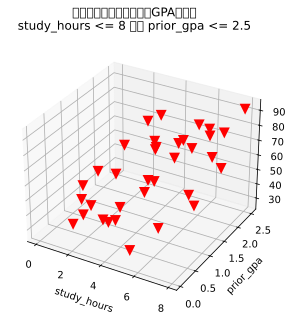

In [8]:
表題 '介入の焦点：低努力・低GPAの学生';
title2 'study_hours <= 8 かつ prior_gpa <= 2.5';
footnote j=r '各マーカーから自習時間×GPAの床面へニードルを下ろす ';

処理 g3d データ=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   条件 study_hours <= 8 かつ prior_gpa <= 2.5;
   見出 study_hours = '週間自習時間'
         prior_gpa   = '前学期GPA'
         exam_score  = '期末試験得点';
実行;
QUIT;


## 結果の解釈

**応答サーフェス**（ステップ2～4）は明確な収穫逓減の稜線を示す。99セルのグリッド全体で予測得点は約26（自習時間ゼロ、GPAゼロ）から約99（高自習時間・高GPAの隅）まで及び、グリッド全体の平均はおよそ70である。自習時間軸に沿って読むと、得点は0からおよそ10時間に向かって急上昇し、それ以降は追加の時間が逓減する収穫しかもたらさないため平坦化する；GPA軸に沿って読むと、前学期の成績はサーフェス全体を押し上げる。交互作用項により、優秀な学生ほど自習時間の見返りがやや急になり、これがサーフェスが平面としてではなくその遠い隅に向かって傾く理由である。

**学生パネル**（ステップ6～7）は個人レベルでもモデルが成立することを裏付ける。100名のコホートは20名の*優秀*、47名の*合格*、33名の*要注意*に分かれる。バンドパネルでは、20個の緑の*優秀*ダイヤモンド——全員が85点以上——が前学期GPA2.2以上かつ週間自習時間約6時間以上に位置し、床面の右上に集まっている。33個の赤の*要注意*マーカーは低努力・低GPAの領域、まさにサーフェスの谷に集中している。コホート別に分けると、秋学期（41名）と春学期（59名）の分布は概ね似ており、成果が入学時期ではなく2つの要因によって駆動されていることを示唆する。

**WHEREで絞り込んだビュー**（ステップ8）は介入対象の集団を特定する：自習時間8時間以下かつGPA2.5以下の35名の学生である。22名が既に*要注意*であり、*優秀*に達しているのはわずか1名である。この隅の中でも、実現得点は自習時間とともに目に見えて上昇しており——構造化された自習時間のわずかな増加が、まさに最も必要とされている場所で最大の限界的利得をもたらすという具体的で視覚的な論拠となっている。

総合すると、PROC G3Dは2要因の交互作用モデルを、得点の上限がどこにあるか、誰がそれに届いていないか、どこに指導努力を注げば最も効果的かを示す、直感的で意思決定に使える1枚の絵に変える。

> **実装上の注記。** SAS/GRAPHでは、単一のSCATTER文で観測値ごとの変数（`COLOR=<charvar>`、`SHAPE=<charvar>`）からすべてのマーカーの色と形状を決めることもできる。この観測値ごとの形式はこのエンジンではまだ描画されないため、このノートブックは代わりにバンドごとに1つのリテラルな色分けパネルを描画する——同等かつ完全に機能する表現である。このギャップはバンク済みの回帰テスト`tests/401000_nb_g3d_scatter_color_variable_unrendered`で追跡されている。
